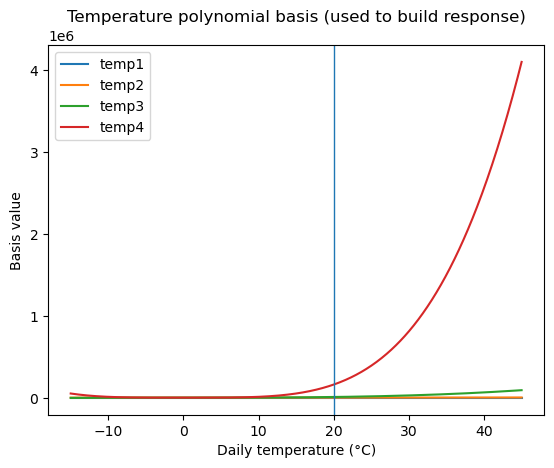

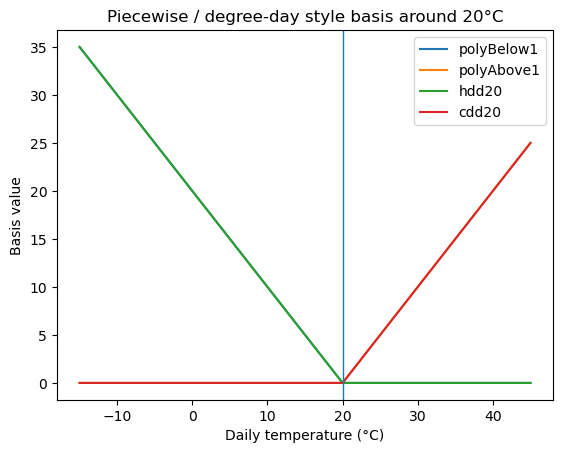

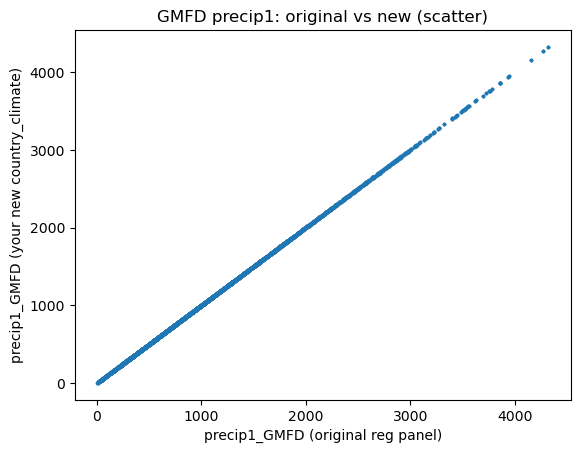

,old_precip1_mean,new_precip1_mean,old_precip2_mean,new_precip2_mean
0,1078.159735,1078.159735,239359.645793,239359.645793


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Temperature basis functions (paper-style)
# -----------------------------
TMIN, TMAX = -15.0, 45.0
T = np.linspace(TMIN, TMAX, 800)

def basis(T):
    T1 = T
    T2 = T**2
    T3 = T**3
    T4 = T**4

    HDD20 = np.where(T < 20, 20 - T, 0.0)
    CDD20 = np.where(T >= 20, T - 20, 0.0)

    ABV1 = np.where(T >= 20, T - 20, 0.0)
    ABV2 = np.where(T >= 20, T**2 - 20**2, 0.0)
    ABV3 = np.where(T >= 20, T**3 - 20**3, 0.0)
    ABV4 = np.where(T >= 20, T**4 - 20**4, 0.0)

    BLW1 = np.where(T < 20, 20 - T, 0.0)
    BLW2 = np.where(T < 20, 20**2 - T**2, 0.0)
    BLW3 = np.where(T < 20, 20**3 - T**3, 0.0)
    BLW4 = np.where(T < 20, 20**4 - T**4, 0.0)

    return {
        "temp1": T1, "temp2": T2, "temp3": T3, "temp4": T4,
        "polyAbove1": ABV1, "polyAbove2": ABV2, "polyAbove3": ABV3, "polyAbove4": ABV4,
        "polyBelow1": BLW1, "polyBelow2": BLW2, "polyBelow3": BLW3, "polyBelow4": BLW4,
        "hdd20": HDD20, "cdd20": CDD20,
    }

B = basis(T)

# ---- Plot: polynomial terms ----
plt.figure()
for k in ["temp1", "temp2", "temp3", "temp4"]:
    plt.plot(T, B[k], label=k)
plt.axvline(20, linewidth=1)
plt.title("Temperature polynomial basis (used to build response)")
plt.xlabel("Daily temperature (°C)")
plt.ylabel("Basis value")
plt.legend()
plt.show()

# ---- Plot: piecewise terms at 20°C ----
plt.figure()
for k in ["polyBelow1", "polyAbove1", "hdd20", "cdd20"]:
    plt.plot(T, B[k], label=k)
plt.axvline(20, linewidth=1)
plt.title("Piecewise / degree-day style basis around 20°C")
plt.xlabel("Daily temperature (°C)")
plt.ylabel("Basis value")
plt.legend()
plt.show()

# -----------------------------
# 2) OPTIONAL: turn basis into an "illustrative response curve"
#    (if you have coefficients for a specific flow/product)
# -----------------------------
# If you export coefficients to a dict like:
# coefs = {"temp1": ..., "temp2": ..., "polyBelow1": ..., "polyAbove1": ..., ...}
# then this plots f(T) = sum_k coef_k * basis_k(T)

def plot_response_from_coefs(coefs, title="Implied response from coefficients"):
    y = np.zeros_like(T)
    for name, beta in coefs.items():
        if name not in B:
            continue
        y += beta * B[name]
    plt.figure()
    plt.plot(T, y)
    plt.axvline(20, linewidth=1)
    plt.title(title)
    plt.xlabel("Daily temperature (°C)")
    plt.ylabel("Implied response (units depend on regression)")
    plt.show()

# Example placeholder (delete / replace):
# plot_response_from_coefs({"temp1": 0.0, "temp2": 0.0, "polyBelow1": 0.0, "polyAbove1": 0.0},
#                          title="(Placeholder) response curve")

# -----------------------------
# 3) Precip sanity: original vs your new GMFD panel (quick compare)
# -----------------------------
import pathlib

old_path = pathlib.Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/GMFD_TINV_clim_regsort.dta")
new_path = pathlib.Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/country_climate/GMFD/GMFD_country_year_1971_2010.csv")

old = pd.read_stata(old_path, columns=["country","year","precip1_GMFD","precip2_GMFD"])
old = old.rename(columns={"country":"iso"})
new = pd.read_csv(new_path, usecols=["iso","year","precip1_GMFD","precip2_GMFD"])

m = old.merge(new, on=["iso","year"], suffixes=("_old","_new"))

plt.figure()
plt.scatter(m["precip1_GMFD_old"], m["precip1_GMFD_new"], s=3)
plt.title("GMFD precip1: original vs new (scatter)")
plt.xlabel("precip1_GMFD (original reg panel)")
plt.ylabel("precip1_GMFD (your new country_climate)")
plt.show()

# If you want a slide-friendly summary:
summ = pd.DataFrame({
    "old_precip1_mean": [m["precip1_GMFD_old"].mean()],
    "new_precip1_mean": [m["precip1_GMFD_new"].mean()],
    "old_precip2_mean": [m["precip2_GMFD_old"].mean()],
    "new_precip2_mean": [m["precip2_GMFD_new"].mean()],
})
summ


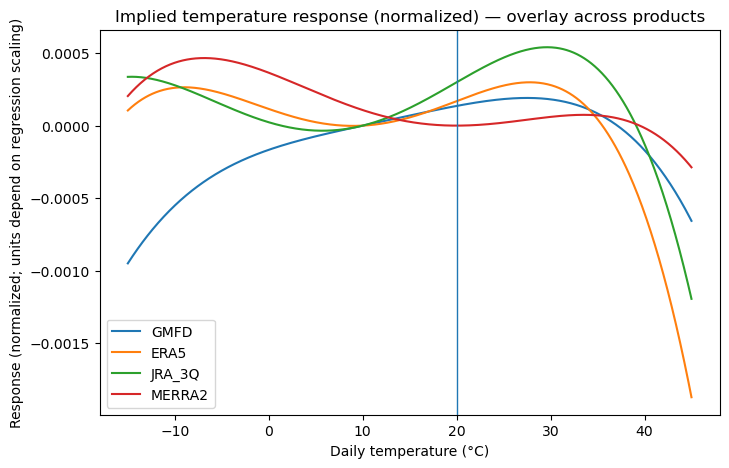

,product,n_terms_used,terms_used
1,ERA5,4,"temp1, temp2, temp3, temp4"
0,GMFD,4,"temp1, temp2, temp3, temp4"
2,JRA_3Q,4,"temp1, temp2, temp3, temp4"
3,MERRA2,4,"temp1, temp2, temp3, temp4"


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# USER EDIT: coefficient CSV paths per product
# -----------------------------
COEF_PATHS = {
    "GMFD": Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_global_GMFD_coeff.csv"),
    "ERA5": Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_global_ERA5_coeff.csv"),
    "JRA_3Q": Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_global_JRA_3Q_coeff.csv"),
    "MERRA2": Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_global_MERRA2_coeff.csv"),
}

# Temperature domain for response curves
TMIN, TMAX = -15.0, 45.0
T = np.linspace(TMIN, TMAX, 800)

# -----------------------------
# Basis functions (match your construction)
# -----------------------------
def temp_basis(T):
    # Polynomials in T
    out = {
        "temp1": T,
        "temp2": T**2,
        "temp3": T**3,
        "temp4": T**4,
    }
    # Piecewise around 20C (these correspond to your polyAbove/polyBelow defs)
    out.update({
        "polyAbove1": np.where(T >= 20, T - 20, 0.0),
        "polyAbove2": np.where(T >= 20, T**2 - 20**2, 0.0),
        "polyAbove3": np.where(T >= 20, T**3 - 20**3, 0.0),
        "polyAbove4": np.where(T >= 20, T**4 - 20**4, 0.0),

        "polyBelow1": np.where(T < 20, 20 - T, 0.0),
        "polyBelow2": np.where(T < 20, 20**2 - T**2, 0.0),
        "polyBelow3": np.where(T < 20, 20**3 - T**3, 0.0),
        "polyBelow4": np.where(T < 20, 20**4 - T**4, 0.0),
    })
    return out

B = temp_basis(T)

# -----------------------------
# Helper: read coefficient CSV and standardize columns
# -----------------------------
def read_coef_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    # Common column name variants across export scripts
    # Try to find: parameter/term name + estimate
    name_candidates = ["parm", "term", "variable", "var", "name"]
    est_candidates = ["estimate", "b", "coef", "coefficient", "beta"]

    name_col = next((c for c in name_candidates if c in df.columns), None)
    est_col  = next((c for c in est_candidates if c in df.columns), None)

    if name_col is None or est_col is None:
        raise ValueError(f"Couldn't identify columns in {path}. Columns={list(df.columns)}")

    out = df[[name_col, est_col]].copy()
    out.columns = ["term", "beta"]
    out["term"] = out["term"].astype(str)
    out["beta"] = pd.to_numeric(out["beta"], errors="coerce")
    out = out.dropna(subset=["beta"])
    return out

# -----------------------------
# Helper: pick the "main" coefficient for each basis component
# Robust to interactions / factor notation by preferring the simplest match.
# -----------------------------
def pick_beta(df: pd.DataFrame, token: str) -> float | None:
    """
    token like 'FD_temp1' or 'FD_polyAbove2'.
    If multiple rows match (e.g., interactions), choose the 'simplest' one.
    """
    # exact contains token as a whole word-ish component
    # (works for e.g. 'FD_temp1', 'c.FD_temp1', '...#c.FD_temp1', etc.)
    pat = re.compile(rf"(^|[^A-Za-z0-9_]){re.escape(token)}([^A-Za-z0-9_]|$)")
    cand = df[df["term"].apply(lambda s: bool(pat.search(s)))]
    if cand.empty:
        return None

    # Prefer terms that do NOT include interaction symbols (#, :, *)
    # and shorter names (usually the raw regressor)
    cand = cand.assign(
        has_interaction=cand["term"].str.contains(r"[#:*]"),
        length=cand["term"].str.len()
    ).sort_values(["has_interaction", "length"])

    return float(cand.iloc[0]["beta"])

# -----------------------------
# Build implied response curve for ONE product
# -----------------------------
def implied_temp_response(df_coef: pd.DataFrame) -> tuple[np.ndarray, dict]:
    """
    Returns y(T) and dict of chosen betas.
    We use the FD_* coefficients if available.
    """
    # Try FD_ naming first (since you're plotting "response" in FD space / yearly sums)
    tokens = {
        "temp1": "FD_temp1",
        "temp2": "FD_temp2",
        "temp3": "FD_temp3",
        "temp4": "FD_temp4",
        "polyAbove1": "FD_polyAbove1",
        "polyAbove2": "FD_polyAbove2",
        "polyAbove3": "FD_polyAbove3",
        "polyAbove4": "FD_polyAbove4",
        "polyBelow1": "FD_polyBelow1",
        "polyBelow2": "FD_polyBelow2",
        "polyBelow3": "FD_polyBelow3",
        "polyBelow4": "FD_polyBelow4",
    }

    betas = {}
    for k, tok in tokens.items():
        b = pick_beta(df_coef, tok)
        if b is not None:
            betas[k] = b

    if not betas:
        # Fall back to non-FD names (less likely, but sometimes exports differ)
        tokens2 = {k: k for k in B.keys()}
        for k, tok in tokens2.items():
            b = pick_beta(df_coef, tok)
            if b is not None:
                betas[k] = b

    # Build y(T) = sum beta_k * basis_k(T)
    y = np.zeros_like(T)
    for k, b in betas.items():
        if k in B:
            y += b * B[k]

    return y, betas

# -----------------------------
# Normalize curve: subtract baseline (common in these papers)
# Here: subtract the minimum over [10,25]C by default (you can change this)
# -----------------------------
def normalize_curve(y, lo=10.0, hi=25.0):
    mask = (T >= lo) & (T <= hi)
    baseline = np.min(y[mask])
    return y - baseline

# -----------------------------
# MAIN: build and plot overlays
# -----------------------------
curves = {}
beta_used = {}

for prod, pth in COEF_PATHS.items():
    dfc = read_coef_csv(pth)
    y, betas = implied_temp_response(dfc)
    yN = normalize_curve(y, lo=10, hi=25)
    curves[prod] = yN
    beta_used[prod] = betas

# Plot overlay
plt.figure(figsize=(8,5))
for prod, y in curves.items():
    plt.plot(T, y, label=prod)
plt.axvline(20, linewidth=1)
plt.title("Implied temperature response (normalized) — overlay across products")
plt.xlabel("Daily temperature (°C)")
plt.ylabel("Response (normalized; units depend on regression scaling)")
plt.legend()
plt.show()

# Quick diagnostics: what coefficients did we actually use?
pd.DataFrame({
    "product": list(beta_used.keys()),
    "n_terms_used": [len(beta_used[p]) for p in beta_used],
    "terms_used": [", ".join(sorted(beta_used[p].keys())) for p in beta_used],
}).sort_values("product")


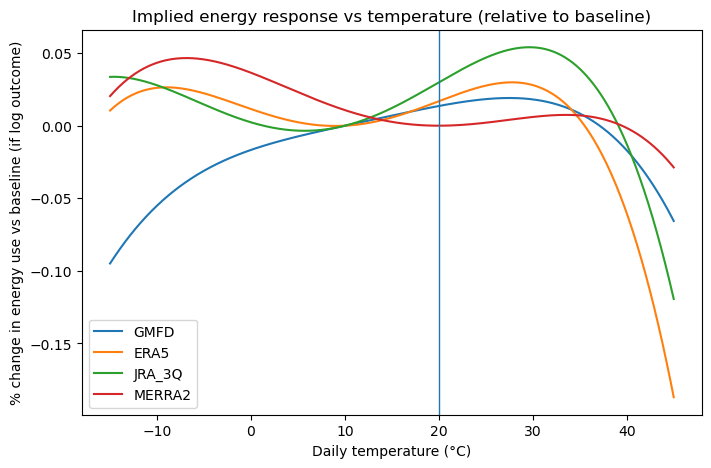

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Choose a baseline temperature range (common choice: min over 10–25C)
def normalize_index(y, lo=10.0, hi=25.0, T=None):
    mask = (T >= lo) & (T <= hi)
    return y - np.min(y[mask])

def to_percent_change_from_log_index(I):
    # If dependent variable is log(load_pc) or log energy, this is % change vs baseline
    return 100.0 * (np.exp(I) - 1.0)

# ---- assuming you already have T and curves[prod] as "index" curves ----
# BUT: your curves are currently normalized already; instead keep an unnormalized copy if possible.
# If you only have normalized curves, that's fine—those are "I(T) - I(T0)" already.

plt.figure(figsize=(8,5))
for prod, I_norm in curves.items():
    pct = to_percent_change_from_log_index(I_norm)
    plt.plot(T, pct, label=prod)

plt.axvline(20, linewidth=1)
plt.title("Implied energy response vs temperature (relative to baseline)")
plt.xlabel("Daily temperature (°C)")
plt.ylabel("% change in energy use vs baseline (if log outcome)")
plt.legend()
plt.show()


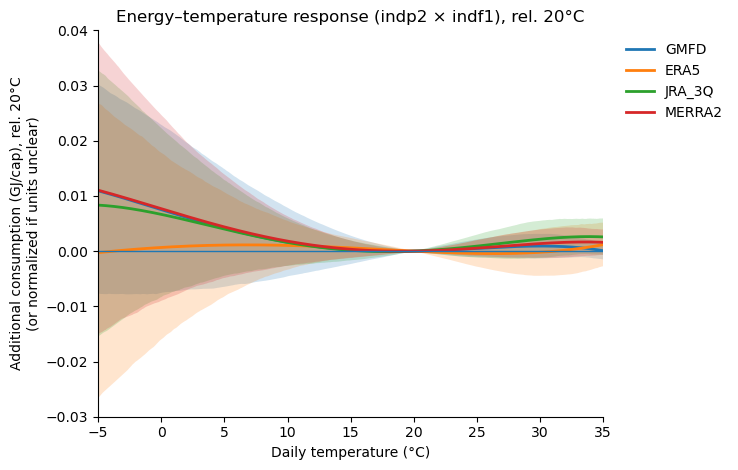

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

COEF_PATHS = {
    "GMFD":   Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_global_GMFD_coeff.csv"),
    "ERA5":   Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_global_ERA5_coeff.csv"),
    "JRA_3Q": Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_global_JRA_3Q_coeff.csv"),
    "MERRA2": Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_global_MERRA2_coeff.csv"),
}

VCOV_PATHS = {
    k: Path(str(v).replace("_coeff.csv", "_vcov_long.csv"))
    for k, v in COEF_PATHS.items()
}

TMIN, TMAX = -5.0, 35.0
T = np.linspace(TMIN, TMAX, 600)

# index closest to 20C on this grid (use consistently)
I20 = int(np.argmin(np.abs(T - 20.0)))

def read_coeff(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    # export uses: parm, beta
    return pd.Series(df["beta"].values, index=df["parm"].astype(str).values)

def read_vcov_long(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["parm_i"] = df["parm_i"].astype(str)
    df["parm_j"] = df["parm_j"].astype(str)
    return df

def vcov_submatrix(vlong: pd.DataFrame, names: list[str]) -> np.ndarray:
    sub = vlong[vlong["parm_i"].isin(names) & vlong["parm_j"].isin(names)]
    if sub.shape[0] != len(names) * len(names):
        missing = set((i, j) for i in names for j in names) - set(zip(sub["parm_i"], sub["parm_j"]))
        raise ValueError(f"VCV missing entries for some pairs, e.g. {list(missing)[:5]}")
    V = (sub.pivot(index="parm_i", columns="parm_j", values="v")
            .reindex(index=names, columns=names)
            .values.astype(float))
    return V

def implied_quartic(T, b1, b2, b3, b4):
    return b1*T + b2*T**2 + b3*T**3 + b4*T**4

def normalize_relative_to_20C_1d(y: np.ndarray) -> np.ndarray:
    """y is (len(T),)"""
    return y - y[I20]

def normalize_relative_to_20C_2d(Y: np.ndarray) -> np.ndarray:
    """Y is (n_draws, len(T))"""
    return Y - Y[:, I20][:, None]

def mc_band_for_product(prod: str, pg: int = 1, n_draws: int = 2000, seed: int = 123):
    coef = read_coeff(COEF_PATHS[prod])
    vlong = read_vcov_long(VCOV_PATHS[prod])

    # EXACT term names from your do-file
    names = [f"c.indp{pg}#c.indf1#c.FD_temp{k}" for k in range(1, 5)]

    # point estimate vector
    b = np.array([coef.get(n, np.nan) for n in names], dtype=float)
    if np.any(np.isnan(b)):
        missing = [names[i] for i in range(4) if np.isnan(b[i])]
        raise ValueError(f"{prod}: missing coeffs {missing}. Check export / term names.")

    # VCV for these 4 coeffs
    V = vcov_submatrix(vlong, names)

    # point curve (1D)
    y_hat = implied_quartic(T, *b)
    y_hat = normalize_relative_to_20C_1d(y_hat)

    # MC draws
    rng = np.random.default_rng(seed)
    draws = rng.multivariate_normal(mean=b, cov=V, size=n_draws)  # (n_draws,4)

    # Y is (n_draws, len(T))
    Y = implied_quartic(
        T[None, :],
        draws[:, 0][:, None],
        draws[:, 1][:, None],
        draws[:, 2][:, None],
        draws[:, 3][:, None],
    )

    # normalize EACH draw to 20C (no np.interp on 2D!)
    YN = normalize_relative_to_20C_2d(Y)

    lo, hi = np.percentile(YN, [2.5, 97.5], axis=0)
    return y_hat, lo, hi, names

# ---- plot overlay across 4 products ----
def plot_overlay(pg: int = 1):
    fig, ax = plt.subplots(figsize=(7.5, 4.8))

    for prod in COEF_PATHS:
        y, lo, hi, used = mc_band_for_product(prod, pg=pg)
        ax.fill_between(T, lo, hi, alpha=0.20, linewidth=0)
        ax.plot(T, y, linewidth=2, label=prod)

    ax.axhline(0, linewidth=1)  # “relative to 20C” baseline
    ax.set_xlim(TMIN, TMAX)
    ax.set_ylim(-0.03, 0.04)
    ax.set_xlabel("Daily temperature (°C)")
    ax.set_ylabel("Additional consumption (GJ/cap), rel. 20°C\n(or normalized if units unclear)")
    ax.set_title(f"Energy–temperature response (indp{pg} × indf1), rel. 20°C")
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    return fig, ax

plot_overlay(pg=2)
plt.show()
